# Day 32 Task: Training Experiments
Run the same model in 4 configs; log + compare train/val curves; generate a comparison table.

### 1. Imports and Dataset setup
We load the necessary libraries and the MNIST dataset. We normalize the images to improve training stability.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


### 2. Configurable Model
To easily test different configurations, we build a multi-layer perceptron (MLP) that conditionally includes **Batch Normalization** and **Dropout** based on the parameters passed during initialization.

In [3]:
class ConfigurableMLP(nn.Module):
    def __init__(self, use_bn=False, use_dropout=False):
        super(ConfigurableMLP, self).__init__()
        self.use_bn = use_bn
        self.use_dropout = use_dropout
        
        self.fc1 = nn.Linear(28*28, 256)
        if self.use_bn:
            self.bn1 = nn.BatchNorm1d(256)
        if self.use_dropout:
            self.dropout1 = nn.Dropout(0.3)
            
        self.fc2 = nn.Linear(256, 128)
        if self.use_bn:
            self.bn2 = nn.BatchNorm1d(128)
        if self.use_dropout:
            self.dropout2 = nn.Dropout(0.3)
            
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = torch.relu(x)
        if self.use_dropout:
            x = self.dropout1(x)
            
        x = self.fc2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = torch.relu(x)
        if self.use_dropout:
            x = self.dropout2(x)
            
        x = self.fc3(x)
        return x


### 3. Training Function
This function orchestrates the training for a given configuration. It initializes the model based on the config flags, runs the training loop, evaluates the validation set, and records the learning curves.

In [4]:
def run_experiment(config_name, use_bn, use_dropout, weight_decay, epochs=5):
    print(f'\nRunning experiment: {config_name}')
    model = ConfigurableMLP(use_bn=use_bn, use_dropout=use_dropout)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    
    train_losses, val_losses = [], []
    final_acc = 0
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)
        final_acc = 100 * correct / total
        print(f'Epoch {epoch+1}, Val Acc: {final_acc:.2f}%')
        
    print(f'Finished {config_name} - Final Val Acc: {final_acc:.2f}%')
    return train_losses, val_losses, final_acc


### 4. Running the 4 Configurations
We test 4 different strategies:
1. **Baseline**: No Batch Normalization, No Dropout, No Weight Decay.
2. **BatchNorm**: Using Batch Normalization only.
3. **Dropout**: Using Dropout only.
4. **Full**: Using Batch Normalization, Dropout, and Weight Decay together.

In [5]:
configs = [
    {'name': 'Baseline', 'use_bn': False, 'use_dropout': False, 'weight_decay': 0.0},
    {'name': 'BatchNorm', 'use_bn': True, 'use_dropout': False, 'weight_decay': 0.0},
    {'name': 'Dropout', 'use_bn': False, 'use_dropout': True, 'weight_decay': 0.0},
    {'name': 'Full (BN+Drop+WD)', 'use_bn': True, 'use_dropout': True, 'weight_decay': 1e-4},
]

results = {}
table_data = []

for conf in configs:
    t_losses, v_losses, acc = run_experiment(conf['name'], conf['use_bn'], conf['use_dropout'], conf['weight_decay'])
    results[conf['name']] = {'train': t_losses, 'val': v_losses}
    table_data.append({'Configuration': conf['name'], 'Final Val Accuracy (%)': f'{acc:.2f}'})



Running experiment: Baseline
Epoch 1, Val Acc: 94.45%
Epoch 2, Val Acc: 95.78%
Epoch 3, Val Acc: 96.19%
Epoch 4, Val Acc: 96.77%
Epoch 5, Val Acc: 97.32%
Finished Baseline - Final Val Acc: 97.32%

Running experiment: BatchNorm
Epoch 1, Val Acc: 97.07%
Epoch 2, Val Acc: 97.43%
Epoch 3, Val Acc: 97.59%
Epoch 4, Val Acc: 97.89%
Epoch 5, Val Acc: 98.02%
Finished BatchNorm - Final Val Acc: 98.02%

Running experiment: Dropout
Epoch 1, Val Acc: 94.30%
Epoch 2, Val Acc: 95.44%
Epoch 3, Val Acc: 96.30%
Epoch 4, Val Acc: 96.68%
Epoch 5, Val Acc: 96.49%
Finished Dropout - Final Val Acc: 96.49%

Running experiment: Full (BN+Drop+WD)
Epoch 1, Val Acc: 96.53%
Epoch 2, Val Acc: 97.46%
Epoch 3, Val Acc: 97.67%
Epoch 4, Val Acc: 97.73%
Epoch 5, Val Acc: 97.91%
Finished Full (BN+Drop+WD) - Final Val Acc: 97.91%


### 5. Compare Curves and Show Table
We visualize the training and validation learning curves for all configurations side-by-side, then print the summary comparison table.

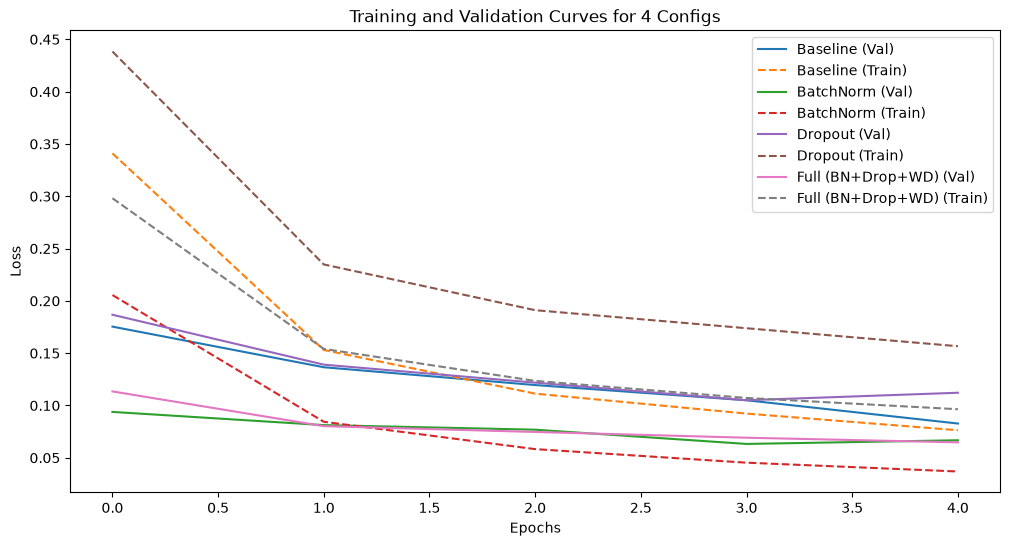


Comparison Table:
Configuration        | Final Val Accuracy (%)
---------------------------------------------
Baseline             | 97.32               
BatchNorm            | 98.02               
Dropout              | 96.49               
Full (BN+Drop+WD)    | 97.91               


In [6]:
plt.figure(figsize=(12, 6))
for name, res in results.items():
    plt.plot(res['val'], label=f'{name} (Val)')
    plt.plot(res['train'], linestyle='--', label=f'{name} (Train)')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Curves for 4 Configs')
plt.legend()
plt.show()

print('\nComparison Table:')
print(f'{"Configuration":<20} | {"Final Val Accuracy (%)":<20}')
print('-' * 45)
for row in table_data:
    print(f'{row["Configuration"]:<20} | {row["Final Val Accuracy (%)"]:<20}')


## Reflection
- **What was difficult:** Deciding how to cleanly toggle Dropout and BatchNorm in the same model class without writing duplicate code.
- **What was improved:** Training curves and configuration comparisons are automated, making it easy to see which combo works best.
- **What remains:** Possibly adding more complex augmentation or learning rate scheduling to further boost performance.